# Resultados da ablação

Análise pós-treino (rode `2_run_ablation.py` antes).

| Seção | O que compara |
|-------|----------------|
| **0. Auditoria** | Contagem wide→final (raw vs mrmr_stable) |
| **1. Eficiência** | Barras mean ± SD; heatmaps e tabela (AUC, BAcc, 

**Runs:** `SELECTION_MODE` × `WITH_COMBAT` → 4 execuções típicas.

**Entrada:** `csvs/longitudinal_4_groups/ablation_results/{modality}/`


In [7]:
# 4 runs típicos: SELECTION_MODE raw|mrmr_stable × WITH_COMBAT False|True

from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from ablation_analysis import (
    prepare_ablation_df,
    selection_audit_report,
)

# --- mudar entre runs ---
SELECTION_MODE = "l1_stable"  # raw | mrmr_stable
WITH_COMBAT = False             # True | False | None

# --- §2 consistência ---
STAB_MODE = "topk"              # topk | single | overview
STAB_CFG = ("smci_pmci", "texture", "svm", False)  # só se STAB_MODE == "single"
STAB_TOP_K = 1
STAB_TOP_N = 25

SAVE_FIGS = False
EXPECTED_FOLDS = 5

MODALITIES = None  # ex.: ("vol", "shape")

MODEL_ORDER = ["svm", "rf", "mlp"]
MOD_ORDER = ["vol", "shape", "texture", "disp", "all"]
TASK_ORDER = ["cn_ad", "cn_smci", "smci_pmci", "smci_ad", "cn_pmci", "pmci_ad"]
TASK_LABELS = {
    "cn_ad": "CN × AD",
    "cn_smci": "CN × sMCI",
    "smci_pmci": "sMCI × pMCI",
    "smci_ad": "sMCI × AD",
    "cn_pmci": "CN × pMCI",
    "pmci_ad": "pMCI × AD",
}
COLOR_MODEL = {"svm": "#4477AA", "rf": "#EE6677", "mlp": "#228833"}
COLOR_MOD = {"vol": "#4477AA", "shape": "#EE6677", "texture": "#228833", "disp": "#CCBB44", "all": "#AA3377"}
EXTRA_METRICS = (
    ("bal_acc_mean", "bal_acc_std", "BAcc"),
    ("f1_pos_mean", "f1_pos_std", "F1"),
    ("sens_pos_mean", "sens_pos_std", "Sens"),
    ("spec_neg_mean", "spec_neg_std", "Spec"),
)
ALL_METRICS = (
    ("auc_mean", "auc_std", "AUC"),
    ("accuracy_mean", "accuracy_std", "Acc"),
    ("auc_pr_mean", "auc_pr_std", "AUC-PR"),
    ("bal_acc_mean", "bal_acc_std", "BAcc"),
    ("mcc_mean", "mcc_std", "MCC"),
    ("f1_pos_mean", "f1_pos_std", "F1"),
    ("sens_pos_mean", "sens_pos_std", "Sens"),
    ("spec_neg_mean", "spec_neg_std", "Spec"),
)

RESULTS_ROOT = Path("csvs/longitudinal_4_groups/ablation_results")
FIGURES_DIR = RESULTS_ROOT / "figures" / SELECTION_MODE
FIGURES_STAB_DIR = FIGURES_DIR / "stability"


def resolve_csv(mod_dir: Path, stem: str) -> Path:
    for name in (f"{stem}_{SELECTION_MODE}.csv", f"{stem}.csv"):
        path = mod_dir / name
        if path.is_file():
            return path
    raise FileNotFoundError(f"{stem} ausente em {mod_dir} (selection={SELECTION_MODE})")


def available_modalities(root: Path) -> list[str]:
    mods = []
    for p in sorted(root.iterdir()):
        if not p.is_dir() or p.name in ("figures",):
            continue
        try:
            resolve_csv(p, "ablation_summary")
            mods.append(p.name)
        except FileNotFoundError:
            pass
    return mods


def load_summaries(modalities: list[str]) -> pd.DataFrame:
    frames = [pd.read_csv(resolve_csv(RESULTS_ROOT / m, "ablation_summary")) for m in modalities]
    return pd.concat(frames, ignore_index=True)


def load_ablation(modalities: list[str]) -> pd.DataFrame:
    frames = [pd.read_csv(resolve_csv(RESULTS_ROOT / m, "ablation_results_all")) for m in modalities]
    return prepare_ablation_df(pd.concat(frames, ignore_index=True))


def prep_df(df: pd.DataFrame, *, filter_run: bool = True) -> pd.DataFrame:
    out = df.copy()
    if filter_run:
        if "selection_mode" in out.columns:
            out = out[out["selection_mode"].astype(str) == SELECTION_MODE]
        if WITH_COMBAT is not None:
            out = out[out["with_combat"] == WITH_COMBAT]
    out["task_label"] = out["task"].map(TASK_LABELS).fillna(out["task"])
    out["model_key"] = pd.Categorical(out["model_key"].astype(str), categories=MODEL_ORDER, ordered=True)
    out["modality"] = pd.Categorical(out["modality"].astype(str), categories=MOD_ORDER, ordered=True)
    present_tasks = [t for t in TASK_ORDER if t in set(out["task"])]
    out["task"] = pd.Categorical(out["task"].astype(str), categories=present_tasks, ordered=True)
    return out.dropna(subset=["task", "model_key", "modality"])


def build_rank_table(df: pd.DataFrame) -> pd.DataFrame:
    """Tabela completa: todas as configs, métricas mean±SD, ordem auc_pooled → bal_acc_mean."""
    rank_cols = [
        "task_label", "modality", "model_key", "with_combat", "selection_mode",
        "auc_pooled", "n_features_mean",
    ]
    rank_cols += [c for mean_col, std_col, _ in ALL_METRICS for c in (mean_col, std_col)]
    rank_cols = [c for c in rank_cols if c in df.columns]
    sort_cols = [c for c in ("auc_pooled", "bal_acc_mean") if c in df.columns]
    rank = df.sort_values(sort_cols, ascending=False)[rank_cols].copy()
    for mean_col, std_col, label in ALL_METRICS:
        if mean_col in rank.columns and std_col in rank.columns:
            rank[f"{label}±std"] = rank.apply(
                lambda r, m=mean_col, s=std_col: fmt_mean_std(r[m], r[s]), axis=1,
            )
    return rank


def rank_show_cols(rank: pd.DataFrame) -> list[str]:
    cols = [
        "task_label", "modality", "model_key", "with_combat", "selection_mode",
        "auc_pooled", "n_features_mean",
    ]
    cols += [f"{label}±std" for _, _, label in ALL_METRICS if f"{label}±std" in rank.columns]
    return [c for c in cols if c in rank.columns]


def save_fig(fig, name: str, *, subdir: Path | None = None) -> Path:
    out_dir = subdir or FIGURES_DIR
    out_dir.mkdir(parents=True, exist_ok=True)
    path = out_dir / f"{name}.pdf"
    if SAVE_FIGS:
        fig.savefig(path, format="pdf", dpi=150, bbox_inches="tight")
        print(f"Salvo: {path}")
    return path


def fmt_mean_std(mean: float, std: float, digits: int = 3) -> str:
    return f"{mean:.{digits}f}±{std:.{digits}f}"


LOADED_MODALITIES = MODALITIES or available_modalities(RESULTS_ROOT)
if not LOADED_MODALITIES:
    raise FileNotFoundError(f"Nenhuma modalidade com summary em {RESULTS_ROOT}")

summary_raw = load_summaries(LOADED_MODALITIES)
df_ablation = load_ablation(LOADED_MODALITIES)
all_results_df = prep_df(summary_raw, filter_run=False)
plot_df = prep_df(summary_raw)
fold_df = prep_df(df_ablation)
rank_table = build_rank_table(all_results_df)

combat_tag = {True: "combat", False: "nocombat", None: "all"}[WITH_COMBAT]
print(f"Modalidades: {LOADED_MODALITIES}")
print(f"Plots filtrados: {SELECTION_MODE} | ComBat: {WITH_COMBAT}")
print(f"Configs (plots): {len(plot_df)} | Folds: {len(fold_df)} | Tabela completa: {len(rank_table)}")
print(f"Figuras §1: {FIGURES_DIR}")
print(f"Figuras §2: {FIGURES_STAB_DIR}")


Modalidades: ['all', 'disp', 'shape', 'texture', 'vol']
Plots filtrados: l1_stable | ComBat: False
Configs (plots): 13 | Folds: 110 | Tabela completa: 13
Figuras §1: csvs/longitudinal_4_groups/ablation_results/figures/l1_stable
Figuras §2: csvs/longitudinal_4_groups/ablation_results/figures/l1_stable/stability


## 0. Auditoria de seleção

Usa `STAB_CFG` (task, modalidade, modelo, combat). Compara modos de seleção no CSV.


In [8]:
audit_task, audit_mod, audit_model, audit_combat = STAB_CFG

audit_sub = df_ablation[
    (df_ablation["task"].astype(str) == audit_task)
    & (df_ablation["model_key"].astype(str) == audit_model)
    & (df_ablation["with_combat"] == audit_combat)
    & (df_ablation["modality"].astype(str) == audit_mod)
]
audit_modes = tuple(sorted(audit_sub["selection_mode"].astype(str).unique()))

display(selection_audit_report(
    df_ablation,
    task=audit_task,
    model=audit_model,
    with_combat=audit_combat,
    modality=audit_mod,
    selection_modes=audit_modes,
))

# display(summarize_selection_audit(audit_sub[audit_sub["selection_mode"].astype(str).isin(audit_modes)]).head(10))



[l1_stable] smci_pmci | texture | svm | combat=False
  wide (inicial):     450 colunas
  após pool estável:  30.0 (média folds)
  após corr/var:      25.8 (média folds)
  selecionados final: 25.8 (média) | min=23 max=28
  removidos pool estável (429): ['L | T1_original_glcm_ClusterProminence', 'L | T1_original_glcm_ClusterShade', 'L | T1_original_glcm_ClusterTendency', 'L | T1_original_glcm_Contrast', 'L | T1_original_glcm_Correlation', 'L | T1_original_glcm_DifferenceAverage', 'L | T1_original_glcm_DifferenceEntropy', 'L | T1_original_glcm_DifferenceVariance', 'L | T1_original_glcm_Id', 'L | T1_original_glcm_Idm', 'L | T1_original_glcm_Idmn', 'L | T1_original_glcm_Idn']
  removidos corr/var (12): ['L | T1_original_glszm_LargeAreaLowGrayLevelEmphasis', 'L | T2_original_gldm_LargeDependenceHighGrayLevelEmphasis', 'L | T2_original_glszm_LargeAreaLowGrayLevelEmphasis', 'L | T3_original_glszm_LargeAreaLowGrayLevelEmphasis', 'R | T1_original_glcm_ClusterShade', 'R | T1_original_glszm_GrayL

,selection_mode,n_wide,n_final_mean,n_removidos_mean
0,l1_stable,450,25.8,424.2


In [9]:
MODS = ["vol", "shape", "texture", "disp"]
STAGES = [
    ("n_features_raw", "wide"),
    ("n_features_after_stable_pool", "após mrmr"),
    ("n_features_after_filters", "após corr/var"),
    ("n_features_selected", "final"),
]

sub = df_ablation[
    df_ablation["modality"].astype(str).isin(MODS)
    & (df_ablation["with_combat"] == WITH_COMBAT)
].copy()

rows = []
for (mod, mode), g in sub.groupby(["modality", "selection_mode"], sort=True):
    row = {"modality": mod, "selection_mode": mode}
    for col, label in STAGES:
        if col in g.columns:
            row[label] = round(g[col].mean(), 1)
    rows.append(row)

feat_summary = pd.DataFrame(rows).sort_values(["modality", "selection_mode"])
display(feat_summary)

,modality,selection_mode,wide,após mrmr,após corr/var,final
0,disp,l1_stable,720.0,36.6,35.8,29.1
1,shape,l1_stable,84.0,57.6,54.8,38.2
2,texture,l1_stable,450.0,30.0,27.2,23.5
3,vol,l1_stable,18.0,15.9,15.8,13.3


## 1. Eficiência dos modelos

Helpers na célula abaixo; **execução com 1 chamada por tarefa/modelo** — edite `title` e `fname`.


In [10]:
# --- §1 Eficiência: estilo e helpers ---

@dataclass
class PlotStyle:
    title_size: int = 11
    label_size: int = 10
    tick_size: int = 8
    annot_size: int = 8
    heatmap_fig: tuple[float, float] = (5.2, 3.8)
    bar_fig: tuple[float, float] = (4.5, 4.0)
    cmap: str = "YlOrRd"
    ref_line: float | None = 0.5


EFF_STYLE = PlotStyle()


def _cat_levels(series: pd.Series, preferred: list | None = None) -> list:
    if hasattr(series, "cat"):
        levels = list(series.cat.categories)
    else:
        levels = sorted(series.dropna().unique())
    if preferred:
        return [v for v in preferred if v in set(levels)] + [v for v in levels if v not in set(preferred)]
    return levels


def _pivot_mean_std(sub: pd.DataFrame, mean_col: str, std_col: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    mean_w = sub.pivot_table(index="model_key", columns="modality", values=mean_col, aggfunc="first", observed=True)
    std_w = sub.pivot_table(index="model_key", columns="modality", values=std_col, aggfunc="first", observed=True)
    mean_w = mean_w.reindex(index=MODEL_ORDER, columns=[m for m in MOD_ORDER if m in mean_w.columns])
    std_w = std_w.reindex(index=MODEL_ORDER, columns=mean_w.columns)
    return mean_w, std_w


def plot_heatmap_task(
    df: pd.DataFrame,
    task_id: str,
    *,
    title: str,
    fname: str,
    mean_col: str = "auc_mean",
    std_col: str = "auc_std",
    vmin: float = 0.5,
    vmax: float = 1.0,
    digits: int = 2,
    cbar_label: str = "AUC (média)",
    style: PlotStyle = EFF_STYLE,
):
    """1 heatmap — edite title e fname."""
    sub = df[df["task"].astype(str) == task_id]
    if sub.empty:
        print(f"Sem dados: {task_id}")
        return
    fig, ax = plt.subplots(figsize=style.heatmap_fig)
    mean_w, std_w = _pivot_mean_std(sub, mean_col, std_col)
    annot = mean_w.copy().astype(object)
    for r in annot.index:
        for c in annot.columns:
            m, s = mean_w.loc[r, c], std_w.loc[r, c]
            annot.loc[r, c] = "" if pd.isna(m) else fmt_mean_std(float(m), float(s), digits)
    sns.heatmap(
        mean_w.astype(float), annot=annot.values, fmt="", cmap=style.cmap,
        vmin=vmin, vmax=vmax, ax=ax, cbar=True, cbar_kws={"label": cbar_label},
        annot_kws={"fontsize": style.annot_size},
    )
    ax.set_title(title, fontsize=style.title_size)
    plt.tight_layout()
    save_fig(fig, fname)
    plt.show()
    plt.close(fig)


def plot_bars(
    data: pd.DataFrame,
    panel: str,
    *,
    col: str,
    title: str,
    fname: str,
    y: str = "auc",
    ylabel: str = "AUC (mean ± SD)",
    x: str = "modality",
    hue: str = "task_label",
    ymin: float = 0.4,
    ymax: float = 1.0,
    errorbar: str | None = "sd",
    style: PlotStyle = EFF_STYLE,
):
    """1 painel de barras — edite title e fname."""
    sub = data.dropna(subset=[x, hue, col, y])
    part = sub[sub[col].astype(str) == str(panel)]
    if part.empty:
        print(f"Sem dados: {panel}")
        return
    fig, ax = plt.subplots(figsize=style.bar_fig)
    order = _cat_levels(
        part[x],
        MOD_ORDER if x == "modality"
        else TASK_ORDER if x == "task"
        else [TASK_LABELS[t] for t in TASK_ORDER] if x == "task_label"
        else None,
    )
    hue_pref = MODEL_ORDER if hue == "model_key" else MOD_ORDER if hue == "modality" else None
    hue_order = _cat_levels(part[hue], hue_pref)
    palette = COLOR_MODEL if hue == "model_key" else (COLOR_MOD if hue == "modality" else None)
    sns.barplot(
        data=part, x=x, y=y, hue=hue,
        order=order, hue_order=hue_order, palette=palette,
        ax=ax, errorbar=errorbar,
        capsize=0.15 if errorbar is not None else 0,
    )
    ax.set_title(str(panel), fontsize=style.label_size)
    ax.set_ylabel(ylabel, fontsize=style.label_size)
    ax.set_ylim(ymin, ymax)
    if style.ref_line is not None:
        ax.axhline(style.ref_line, color="gray", ls="--", lw=0.8)
    ax.tick_params(axis="x", rotation=25, labelsize=style.tick_size)
    ax.tick_params(axis="y", labelsize=style.tick_size)
    ax.legend(fontsize=style.tick_size, loc="best")
    fig.suptitle(title, fontsize=style.title_size)
    plt.tight_layout()
    save_fig(fig, fname)
    plt.show()
    plt.close(fig)


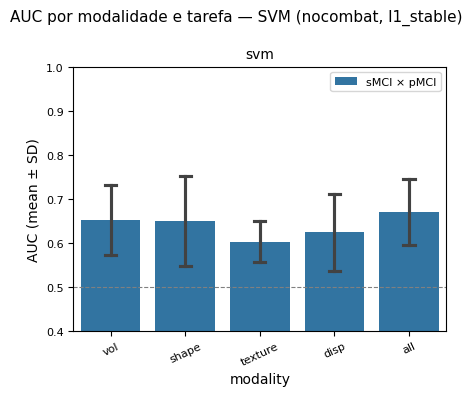

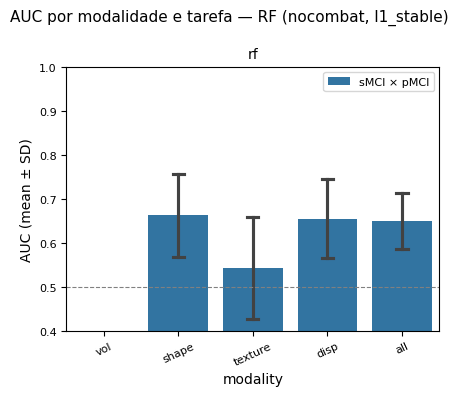

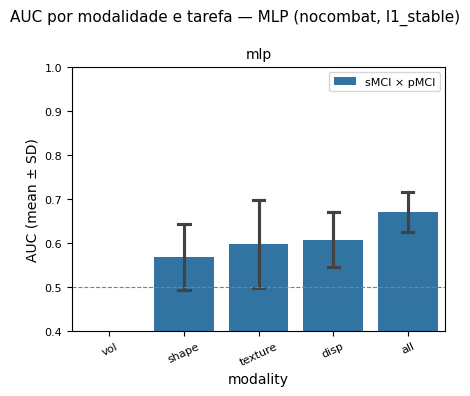

Sem dados: cn_ad


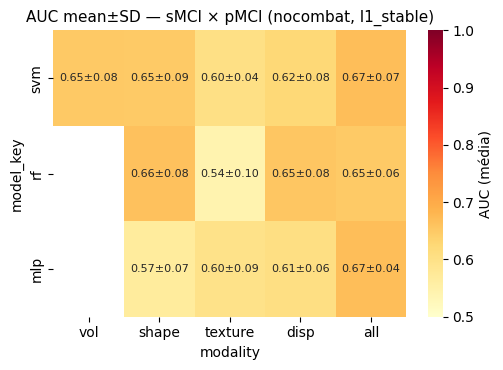


Tabela completa (13 configs): todas as abordagens (selection_mode × with_combat), ordenada por auc_pooled ↓, desempate bal_acc_mean ↓


,task_label,modality,model_key,with_combat,selection_mode,auc_pooled,n_features_mean,AUC±std,Acc±std,AUC-PR±std,BAcc±std,MCC±std,F1±std,Sens±std,Spec±std
0,sMCI × pMCI,all,svm,False,l1_stable,0.660436,61.80,0.669±0.067,0.591±0.076,0.643±0.030,0.602±0.074,0.203±0.146,0.590±0.066,0.680±0.065,0.524±0.097
1,sMCI × pMCI,all,mlp,False,l1_stable,0.658590,61.80,0.669±0.041,0.574±0.018,0.626±0.073,0.566±0.028,0.133±0.055,0.499±0.068,0.506±0.119,0.626±0.069
7,sMCI × pMCI,disp,rf,False,l1_stable,0.654725,35.40,0.654±0.081,0.623±0.062,0.613±0.087,0.625±0.053,0.252±0.109,0.591±0.046,0.631±0.081,0.619±0.129
12,sMCI × pMCI,shape,rf,False,l1_stable,0.649937,53.40,0.662±0.085,0.585±0.077,0.619±0.080,0.596±0.063,0.207±0.128,0.579±0.059,0.668±0.148,0.525±0.202
26,sMCI × pMCI,vol,svm,False,l1_stable,0.646952,15.52,0.651±0.079,0.609±0.069,0.619±0.082,0.606±0.070,0.216±0.144,0.556±0.095,0.584±0.148,0.628±0.129
2,sMCI × pMCI,all,rf,False,l1_stable,0.641745,61.80,0.649±0.056,0.564±0.056,0.584±0.073,0.571±0.047,0.146±0.094,0.543±0.066,0.618±0.146,0.523±0.161
10,sMCI × pMCI,disp,svm,False,l1_stable,0.616476,35.40,0.624±0.078,0.570±0.085,0.605±0.051,0.563±0.072,0.130±0.148,0.503±0.063,0.507±0.101,0.620±0.183
11,sMCI × pMCI,disp,mlp,False,l1_stable,0.615322,35.40,0.607±0.055,0.596±0.059,0.557±0.055,0.582±0.049,0.181±0.106,0.484±0.119,0.481±0.201,0.683±0.207
14,sMCI × pMCI,shape,svm,False,l1_stable,0.613015,53.40,0.649±0.091,0.553±0.094,0.615±0.070,0.552±0.082,0.115±0.174,0.503±0.093,0.545±0.178,0.558±0.219
19,sMCI × pMCI,texture,svm,False,l1_stable,0.606092,25.80,0.602±0.041,0.542±0.044,0.549±0.028,0.532±0.055,0.075±0.118,0.355±0.255,0.438±0.354,0.626±0.288


Salvo: csvs/longitudinal_4_groups/ablation_results/all_results_summary.csv


In [11]:
# --- §1 execução: edite title/fname de cada chamada ---

_ct = f"({combat_tag}, {SELECTION_MODE})"

# AUC — barras por modelo
plot_bars(fold_df, "svm", col="model_key",
    title=f"AUC por modalidade e tarefa — SVM {_ct}",
    fname=f"auc_by_model_svm_{combat_tag}",
)
plot_bars(fold_df, "rf", col="model_key",
    title=f"AUC por modalidade e tarefa — RF {_ct}",
    fname=f"auc_by_model_rf_{combat_tag}",
)
plot_bars(fold_df, "mlp", col="model_key",
    title=f"AUC por modalidade e tarefa — MLP {_ct}",
    fname=f"auc_by_model_mlp_{combat_tag}",
)

# AUC — heatmap por tarefa
plot_heatmap_task(plot_df, "cn_ad",
    title=f"AUC mean±SD — CN × AD {_ct}",
    fname=f"auc_heatmap_cn_ad_{combat_tag}",
)
# plot_heatmap_task(plot_df, "cn_smci",
#     title=f"AUC mean±SD — CN × sMCI {_ct}",
#     fname=f"auc_heatmap_cn_smci_{combat_tag}",
# )
plot_heatmap_task(plot_df, "smci_pmci",
    title=f"AUC mean±SD — sMCI × pMCI {_ct}",
    fname=f"auc_heatmap_smci_pmci_{combat_tag}",
)
# plot_heatmap_task(plot_df, "smci_ad",
#     title=f"AUC mean±SD — sMCI × AD {_ct}",
#     fname=f"auc_heatmap_smci_ad_{combat_tag}",
# )
# plot_heatmap_task(plot_df, "cn_pmci",
#     title=f"AUC mean±SD — CN × pMCI {_ct}",
#     fname=f"auc_heatmap_cn_pmci_{combat_tag}",
# )
# plot_heatmap_task(plot_df, "pmci_ad",
#     title=f"AUC mean±SD — pMCI × AD {_ct}",
#     fname=f"auc_heatmap_pmci_ad_{combat_tag}",
# )

# Métricas extras — descomente o bloco que quiser plotar

# # BAcc — heatmaps
# plot_heatmap_task(plot_df, "cn_ad", mean_col="bal_acc_mean", std_col="bal_acc_std",
#     title=f"BAcc mean±SD — CN × AD {_ct}", fname=f"bacc_heatmap_cn_ad_{combat_tag}",
#     vmin=0.4, cbar_label="BAcc (média)")
# ... (repita para cn_smci, smci_pmci, smci_ad, cn_pmci, pmci_ad)

print(
    f"\nTabela completa ({len(rank_table)} configs): "
    "todas as abordagens (selection_mode × with_combat), "
    "ordenada por auc_pooled ↓, desempate bal_acc_mean ↓"
)
pd.set_option("display.max_rows", None)
display(rank_table[rank_show_cols(rank_table)])

out_path = RESULTS_ROOT / "all_results_summary.csv"
all_results_df.to_csv(out_path, index=False)
print(f"Salvo: {out_path}")

# Gera planilha de todos os testes

In [5]:
from pathlib import Path
import pandas as pd
from IPython.display import display

BASE = Path("csvs/longitudinal_4_groups")
CONFIG_COLS = ["task", "modality", "model_key", "with_combat", "selection_mode"]
PROTOCOL_ROOTS = {
    "abs":              BASE / "ablation_results",
    "t1_only":          BASE / "ablation_results_t1_only",
    "deltas":           BASE / "ablation_results_deltas",
    "deltas_only":      BASE / "ablation_results_deltas_only",
    "deltas_rel":       BASE / "ablation_results_deltas_rel",
    "global":           BASE / "ablation_results_leaky",
    "t1_only_global":   BASE / "ablation_results_leaky_t1_only",
    "clinica":          BASE / "ablation_results_clinic",
    "clinica+img":      BASE / "ablation_results_clinic_img",
    "clinica+img_t1":   BASE / "ablation_results_clinic_img_t1_only",
}


def summary_files(root: Path) -> list[Path]:
    # nível canônico apenas (sem rglob → ignora subpastas aninhadas de runs antigos)
    files = list(root.glob("*/ablation_summary.csv"))            # abs, deltas, global
    files += [f for f in root.glob("*summary*.csv") if not f.name.startswith("all_")]  # clinica(+img)
    return files


frames = []
for proto, root in PROTOCOL_ROOTS.items():
    if not root.is_dir():
        continue
    for f in summary_files(root):
        df = pd.read_csv(f)
        df.insert(0, "protocol", proto)
        df["source_file"] = str(f.relative_to(BASE))
        df["source_mtime"] = pd.Timestamp(f.stat().st_mtime, unit="s")
        frames.append(df)

master = pd.concat(frames, ignore_index=True)

# dedup: mesma config dentro do mesmo protocolo → mantém a mais recente
keys = ["protocol"] + [c for c in CONFIG_COLS if c in master.columns]
master = master.sort_values("source_mtime").drop_duplicates(keys, keep="last")

front = ["protocol", *CONFIG_COLS, "auc_pooled", "auc_mean", "auc_std", "n_features_mean"]
front = [c for c in front if c in master.columns]
master = master[front + [c for c in master.columns if c not in front]]
master = master.sort_values(["protocol", "auc_pooled"], ascending=[True, False]).reset_index(drop=True)

out = BASE / "all_protocols_summary.csv"
master.to_csv(out, index=False)
print(f"Salvo: {out} | {len(master)} linhas")
print(master.groupby("protocol").size().rename("linhas").to_string())
display(master[front])

Salvo: csvs/longitudinal_4_groups/all_protocols_summary.csv | 95 linhas
protocol
abs               10
clinica            4
clinica+img       21
deltas            16
global            24
t1_only           10
t1_only_global    10


,protocol,task,modality,model_key,with_combat,selection_mode,auc_pooled,auc_mean,auc_std,n_features_mean
0,abs,smci_pmci,vol,svm,True,l1_stable,0.686743,0.690052,0.054933,16.6
1,abs,smci_pmci,vol,svm,False,l1_stable,0.678724,0.679397,0.049920,16.0
2,abs,smci_pmci,shape,svm,False,l1_stable,0.625591,0.660215,0.093650,53.4
3,abs,smci_pmci,all,svm,True,l1_stable,0.616592,0.659778,0.077004,50.0
4,abs,smci_pmci,shape,svm,True,l1_stable,0.604188,0.648199,0.074864,53.4
...,...,...,...,...,...,...,...,...,...,...
90,t1_only_global,smci_pmci,vol,svm,True,l1_stable,0.661705,0.673082,0.065892,1.0
91,t1_only_global,smci_pmci,texture,svm,True,l1_stable,0.652821,0.674196,0.074071,2.0
92,t1_only_global,smci_pmci,disp,svm,False,l1_stable,0.497058,0.509565,0.148554,1.0
93,t1_only_global,smci_pmci,texture,svm,False,l1_stable,0.474443,0.429787,0.083974,1.0


# Plot AUC

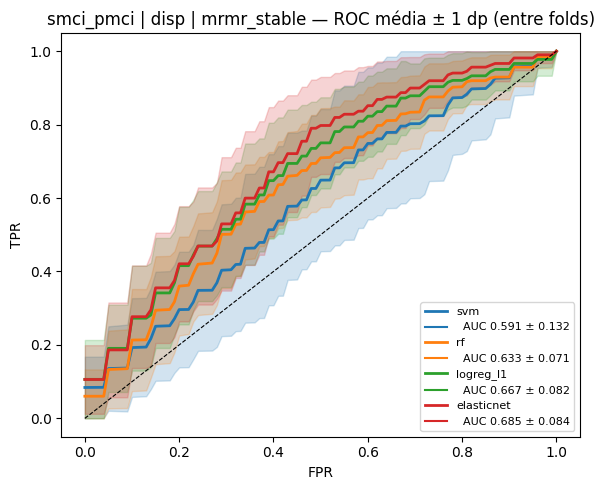

In [39]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, roc_curve

from ablation_analysis import prepare_ablation_df, filter_ablation_config

def interp_tpr(fpr, tpr, grid):
    return np.interp(grid, fpr, tpr, left=0.0, right=1.0)

def roc_mean_std(sub: pd.DataFrame, fpr_grid: np.ndarray):
    tpr_rows, aucs = [], []
    for _, row in sub.iterrows():
        y = np.asarray(json.loads(row["test_y_true"]), dtype=int)
        s = np.asarray(json.loads(row["test_scores"]), dtype=float)
        if len(np.unique(y)) < 2:
            continue
        fpr, tpr, _ = roc_curve(y, s)
        tpr_rows.append(interp_tpr(fpr, tpr, fpr_grid))
        aucs.append(roc_auc_score(y, s))
    if not tpr_rows:
        raise ValueError("Nenhum fold com duas classes")
    tpr_m = np.mean(tpr_rows, axis=0)
    tpr_s = np.std(tpr_rows, axis=0, ddof=0)
    return tpr_m, tpr_s, np.asarray(aucs)

MOD = "all"
df = prepare_ablation_df(
    pd.read_csv(f"csvs/longitudinal_4_groups/ablation_results/{MOD}/ablation_results_all.csv")
)
fpr_grid = np.linspace(0, 1, 101)

fig, ax = plt.subplots(figsize=(6, 5))
colors = {"svm": "C0", "rf": "C1", "logreg_l1": "C2", "elasticnet": "C3"}

for model in ["svm", "rf", "logreg_l1", "elasticnet"]:
    try:
        sub = filter_ablation_config(
            df,
            task="smci_pmci",
            modality=MOD,
            model_key=model,
            with_combat=False,
            selection_mode="mrmr_stable",
        )
        tpr_m, tpr_s, aucs = roc_mean_std(sub, fpr_grid)
        c = colors.get(model, None)
        ax.plot(fpr_grid, tpr_m, color=c, lw=2, label=f"{model}")
        ax.fill_between(
            fpr_grid,
            np.clip(tpr_m - tpr_s, 0, 1),
            np.clip(tpr_m + tpr_s, 0, 1),
            color=c,
            alpha=0.2,
        )
        # legenda com AUC mean ± SD (por fold)
        ax.plot([], [], color=c, label=f"  AUC {aucs.mean():.3f} ± {aucs.std(ddof=0):.3f}")
    except (ValueError, KeyError) as e:
        print(f"{model}: {e}")

ax.plot([0, 1], [0, 1], "k--", lw=0.8)
ax.set_xlabel("FPR")
ax.set_ylabel("TPR")
ax.set_title("smci_pmci | disp | mrmr_stable — ROC média ± 1 dp (entre folds)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()